In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("../data/raw/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [12]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Legitimate:", negative)
print("Fraud:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Legitimate: 199020
Fraud: 344
Scale Pos Weight: 578.546511627907


In [13]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [14]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
xgb_val_pred = xgb_model.predict(X_val)

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]

In [16]:
print(xgb_val_pred[:20])
print(xgb_val_proba[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1.0236846e-05 8.8216211e-06 8.5426136e-06 1.3510571e-04 3.2391856e-06
 6.1160838e-04 1.1696606e-05 6.5479995e-05 1.4636199e-05 2.8312592e-05
 7.5497383e-06 4.6004820e-06 2.4320154e-05 2.4229570e-05 7.8310195e-06
 2.5182810e-06 6.5190405e-05 2.2426133e-05 1.0737769e-05 2.4150381e-06]


In [17]:
xgb_precision = precision_score(
    y_val,
    xgb_val_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_val,
    xgb_val_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_proba
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_proba
)

In [18]:
print("========== XGBOOST ==========")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")
print(f"PR-AUC:    {xgb_pr_auc:.4f}")

========== XGBOOST ==========
Precision: 0.8906
Recall:    0.7703
F1 Score:  0.8261
ROC-AUC:   0.9833
PR-AUC:    0.8344


In [19]:
print(
    classification_report(
        y_val,
        xgb_val_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42647
           1       0.89      0.77      0.83        74

    accuracy                           1.00     42721
   macro avg       0.95      0.89      0.91     42721
weighted avg       1.00      1.00      1.00     42721



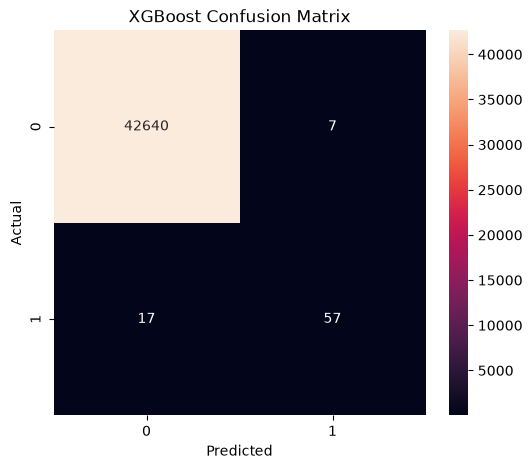

In [20]:
cm = confusion_matrix(
    y_val,
    xgb_val_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
14,V14,0.493072
4,V4,0.076033
10,V10,0.067563
20,V20,0.028494
12,V12,0.026292
29,Amount,0.018974
17,V17,0.018610
13,V13,0.018427
11,V11,0.018368
8,V8,0.016841


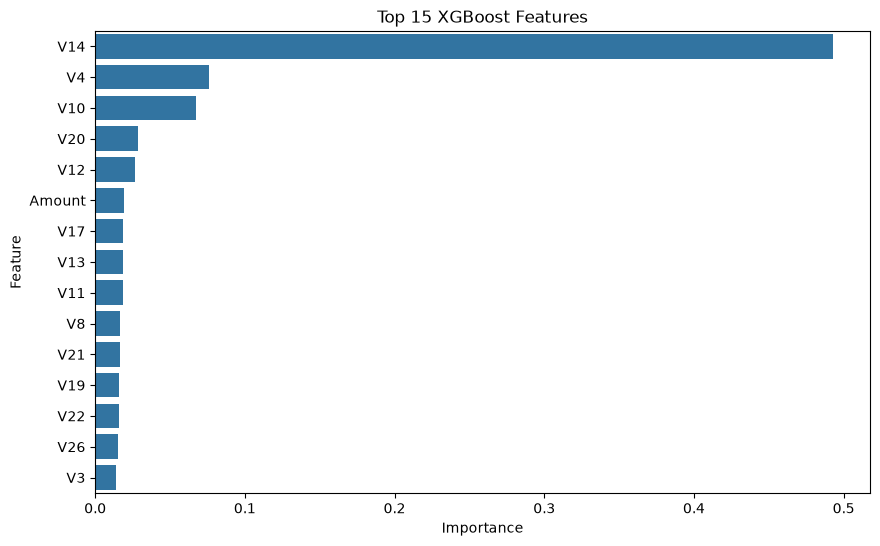

In [22]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 15 XGBoost Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [23]:
model_comparison = pd.DataFrame({
    "XGBoost": {
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1": xgb_f1,
        "ROC-AUC": xgb_roc_auc,
        "PR-AUC": xgb_pr_auc
    }
}).T

model_comparison

,Precision,Recall,F1,ROC-AUC,PR-AUC
XGBoost,0.890625,0.77027,0.826087,0.983317,0.83444


In [24]:
thresholds = np.arange(
    0.05,
    1.00,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        xgb_val_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,threshold,precision,recall,f1
0,0.05,0.543103,0.851351,0.663158
1,0.10,0.677419,0.851351,0.754491
2,0.15,0.746835,0.797297,0.771242
3,0.20,0.776316,0.797297,0.786667
4,0.25,0.828571,0.783784,0.805556
5,0.30,0.852941,0.783784,0.816901
6,0.35,0.863636,0.770270,0.814286
7,0.40,0.863636,0.770270,0.814286
8,0.45,0.863636,0.770270,0.814286
9,0.50,0.890625,0.770270,0.826087


In [25]:
best_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_f1_row

threshold    0.750000
precision    0.904762
recall       0.770270
f1           0.832117
Name: 14, dtype: float64

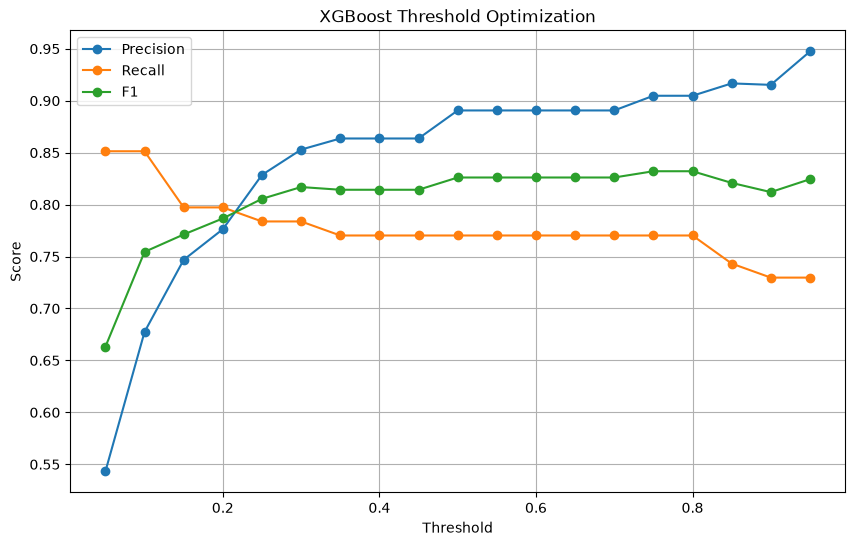

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Optimization")

plt.legend()
plt.grid(True)

plt.show()